# 프로젝트 3: 설비관리 - 예지보전 & 센서 이상탐지

## 프로젝트 배경

당신은 **한국정밀산업(주)** 설비기술팀의 데이터 분석가입니다.  
최근 설비 고장이 연이어 발생하면서 경영진이 **예지보전(Predictive Maintenance)** 시스템 도입을 검토 중입니다.

> *"지난 4월에 EQ-A03 밀링머신이 베어링 고장으로 48시간 정지했고,  
> 5월에는 EQ-C02 CNC선반이 과열로 비상정지했습니다.  
> 센서 데이터를 분석하면 고장을 미리 예측할 수 있을까요?  
> 고장 전에 어떤 징후가 있었는지 분석해 주세요."*

### 분석 목표
1. **센서 데이터 탐색** - 12대 설비의 온도·진동·전류·압력 패턴 파악
2. **이상치 탐지** - 통계적 방법(3-sigma, IQR, 이동평균)으로 이상 신호 탐지
3. **고장 전조 분석** - 고장 발생 전 센서 데이터 변화 패턴 추적
4. **정비 이력 연계** - 정비/고장 이력과 센서 데이터 상관관계 분석
5. **설비 건강도 스코어링** - 설비 상태를 점수화하여 우선순위 도출

### 데이터 설명

| 파일 | 설명 | 주요 컬럼 |
|------|------|----------|
| `p3_equipment.csv` | 설비 마스터 (12대) | equipment_id, cumulative_hours, pm_cycle_days, criticality |
| `p3_sensor_log.csv` | 센서 시계열 (~21,000건, 2시간 주기) | timestamp, temperature_c, vibration_mms, current_a, pressure_bar |
| `p3_maintenance_log.csv` | 정비/고장 이력 (~230건) | maintenance_type(PM/CM/BM/INS), cause, duration_hours, cost_won |
| `p3_alarm_log.csv` | 설비 알람 기록 (~130건) | alarm_type, severity(경고/위험/긴급), acknowledged |

### 정비 유형

| 코드 | 유형 | 설명 |
|------|------|------|
| PM | 예방정비 | 계획된 정기 정비 |
| CM | 고장수리 | 설비 고장 후 수리 |
| BM | 사후보전 | 소규모 사후 조치 |
| INS | 점검 | 일상/주간 점검 |

### 예지보전의 핵심 개념

```
고장 발생 패턴:
  정상 운전 → 초기 징후(미세 변화) → 악화(명확한 이상) → 고장 발생

탐지 방법:
  1. 임계값 기반: 센서값 > 기준치 → 알람
  2. 통계적 방법: 이동평균/표준편차 벗어남 → 이상
  3. 추세 분석: 시간에 따른 변화율 증가 → 열화 진행
```

---

## Part 0: 환경 설정 및 데이터 로드

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')

equip = pd.read_csv('../data/project3/p3_equipment.csv', encoding='utf-8-sig')
sensor = pd.read_csv('../data/project3/p3_sensor_log.csv', encoding='utf-8-sig')
maint = pd.read_csv('../data/project3/p3_maintenance_log.csv', encoding='utf-8-sig')
alarm = pd.read_csv('../data/project3/p3_alarm_log.csv', encoding='utf-8-sig')

sensor['timestamp'] = pd.to_datetime(sensor['timestamp'])
maint['date'] = pd.to_datetime(maint['date'])
alarm['timestamp'] = pd.to_datetime(alarm['timestamp'])

print('데이터 로드 완료!')
print(f'설비: {len(equip)}건 | 센서: {len(sensor):,}건 | 정비: {len(maint)}건 | 알람: {len(alarm)}건')

데이터 로드 완료!
설비: 12건 | 센서: 21,750건 | 정비: 230건 | 알람: 132건


---
## Part 1: 데이터 탐색 및 전처리 (15점)

센서 데이터는 2시간 간격으로 수집되며, 센서 오류/통신 장애로 결측치가 포함됩니다.  
시계열 데이터에서의 결측치는 **보간(interpolation)**으로 처리하는 것이 일반적입니다.

### 문제 1-1: 데이터 탐색 (5점)

1. 4개 데이터프레임의 기본 정보(shape, dtypes)를 확인하세요
2. `sensor` 데이터의 결측치 현황을 컬럼별로 확인하세요
3. `sensor` 데이터의 기간(시작~끝), 설비별 건수를 확인하세요
4. `maint` 데이터의 정비 유형별 건수를 확인하세요
5. `equip` 테이블에서 설비별 누적가동시간과 중요도(criticality)를 확인하세요

In [8]:
sensor.isna().sum()

sensor_id          0
timestamp          0
equipment_id       0
temperature_c    435
vibration_mms    706
current_a        233
pressure_bar     192
dtype: int64

In [9]:
sensor['timestamp'].min()

Timestamp('2024-01-01 00:00:00')

In [10]:
sensor['timestamp'].max()

Timestamp('2024-06-29 22:00:00')

In [12]:
sensor['equipment_id'].value_counts()

equipment_id
EQ-B01    1829
EQ-A02    1827
EQ-C01    1827
EQ-B04    1826
EQ-C04    1826
EQ-B02    1818
EQ-A04    1816
EQ-B03    1815
EQ-C03    1800
EQ-A01    1797
EQ-C02    1786
EQ-A03    1783
Name: count, dtype: int64

In [14]:
maint['maintenance_type'].value_counts()

maintenance_type
INS    166
BM      30
PM      19
CM      15
Name: count, dtype: int64

In [15]:
equip.columns

Index(['equipment_id', 'equipment_name', 'line', 'equipment_type',
       'install_date', 'cumulative_hours', 'pm_cycle_days', 'last_pm_date',
       'criticality'],
      dtype='object')

In [18]:
equip[ ['equipment_id', 'equipment_name', 'line','cumulative_hours','criticality' ]] 

,equipment_id,equipment_name,line,cumulative_hours,criticality
0,EQ-A01,CNC선반-A1,A라인,12500,A
1,EQ-A02,CNC선반-A2,A라인,12100,B
2,EQ-A03,밀링머신-A3,A라인,10800,A
3,EQ-A04,드릴프레스-A4,A라인,10200,C
4,EQ-B01,CNC선반-B1,B라인,5800,B
5,EQ-B02,CNC선반-B2,B라인,5500,B
6,EQ-B03,밀링머신-B3,B라인,4200,A
7,EQ-B04,드릴프레스-B4,B라인,3900,C
8,EQ-C01,CNC선반-C1,C라인,8500,B
9,EQ-C02,CNC선반-C2,C라인,8200,A


In [3]:
# 여기에 코드 작성
equip.shape

(12, 9)

In [5]:
sensor['timestamp'].unique()

<DatetimeArray>
['2024-01-01 00:00:00', '2024-01-01 02:00:00', '2024-01-01 04:00:00',
 '2024-01-01 06:00:00', '2024-01-01 08:00:00', '2024-01-01 10:00:00',
 '2024-01-01 12:00:00', '2024-01-01 14:00:00', '2024-01-01 16:00:00',
 '2024-01-01 18:00:00',
 ...
 '2024-06-29 04:00:00', '2024-06-29 06:00:00', '2024-06-29 08:00:00',
 '2024-06-29 10:00:00', '2024-06-29 12:00:00', '2024-06-29 14:00:00',
 '2024-06-29 16:00:00', '2024-06-29 18:00:00', '2024-06-29 20:00:00',
 '2024-06-29 22:00:00']
Length: 1872, dtype: datetime64[ns]

In [6]:
maint

,maintenance_id,date,equipment_id,maintenance_type,description,cause,duration_hours,cost_won,parts_replaced,technician_id
0,MT-00001,2024-01-01,EQ-A02,INS,주간점검 - 일상점검,일상점검,1.0,14000,NaN,TECH-08
1,MT-00002,2024-01-01,EQ-B01,INS,주간점검 - 진동측정,진동측정,1.0,24000,NaN,TECH-01
2,MT-00003,2024-01-01,EQ-C01,INS,주간점검 - 온도측정,온도측정,2.0,42000,NaN,TECH-07
3,MT-00004,2024-01-03,EQ-C02,BM,사후보전 - 소모품교체,소모품교체,3.0,105000,베어링,TECH-07
4,MT-00005,2024-01-04,EQ-C03,CM,고장수리 - 모터과열,모터과열,46.0,1237000,NaN,TECH-04
...,...,...,...,...,...,...,...,...,...,...
225,MT-00226,2024-06-24,EQ-C03,INS,주간점검 - 진동측정,진동측정,2.0,37000,NaN,TECH-02
226,MT-00227,2024-06-25,EQ-A01,BM,사후보전 - 윤활,윤활,2.0,144000,베어링,TECH-03
227,MT-00228,2024-06-25,EQ-C02,BM,사후보전 - 볼트조임,볼트조임,2.0,37000,오일,TECH-08
228,MT-00229,2024-06-28,EQ-A03,CM,고장수리 - 냉각계통이상,냉각계통이상,23.0,424000,NaN,TECH-06


In [7]:
alarm

,alarm_id,timestamp,equipment_id,alarm_type,alarm_value,threshold,severity,acknowledged,resolved
0,ALM-00001,2024-01-02 06:00:00,EQ-A03,CRITICAL_VIBRATION,9.10,8.0,위험,False,False
1,ALM-00002,2024-01-02 08:00:00,EQ-A02,CRITICAL_VIBRATION,9.38,8.0,위험,True,True
2,ALM-00003,2024-01-04 00:00:00,EQ-B03,HIGH_VIBRATION,6.05,5.0,경고,True,True
3,ALM-00004,2024-01-04 20:00:00,EQ-A02,HIGH_VIBRATION,6.96,5.0,경고,False,True
4,ALM-00005,2024-01-08 18:00:00,EQ-C01,HIGH_TEMP,59.10,55.0,경고,True,True
...,...,...,...,...,...,...,...,...,...
127,ALM-00128,2024-06-20 08:00:00,EQ-C04,CRITICAL_VIBRATION,9.29,8.0,위험,True,True
128,ALM-00129,2024-06-26 10:00:00,EQ-C04,CRITICAL_VIBRATION,9.08,8.0,위험,True,False
129,ALM-00130,2024-06-26 16:00:00,EQ-A03,HIGH_TEMP,63.00,55.0,경고,True,True
130,ALM-00131,2024-06-28 12:00:00,EQ-A01,CRITICAL_VIBRATION,9.25,8.0,위험,False,True


### 문제 1-2: 센서 데이터 결측치 처리 (5점)

시계열 센서 데이터의 결측치는 **설비별 시간순 보간**이 가장 적합합니다.

1. 설비별로 그룹화한 후, 수치형 컬럼의 결측치를 **선형 보간(interpolate)**으로 처리
2. 보간 후에도 남는 결측치(시작/끝 부분)는 **전방/후방 채움(ffill/bfill)**으로 처리
3. 처리 후 결측치가 0인지 확인

In [23]:
sensor = sensor.sort_values(['equipment_id', 'timestamp']).reset_index(drop=True)

In [24]:
sensor.isna().sum()

sensor_id          0
timestamp          0
equipment_id       0
temperature_c    435
vibration_mms    706
current_a        233
pressure_bar     192
dtype: int64

In [25]:
cols = ['temperature_c','vibration_mms','current_a','pressure_bar']

In [26]:
def trans(x) :
    return x.interpolate(method='linear')

In [28]:
sensor[cols] = sensor.groupby('equipment_id')[cols].transform( trans  )

In [29]:
sensor.isna().sum()

sensor_id        0
timestamp        0
equipment_id     0
temperature_c    0
vibration_mms    0
current_a        0
pressure_bar     0
dtype: int64

In [30]:
# 맨 윗행(맨 위 데이터) 또는 맨 아래행(맨 아래 데이터)가 비어있을수가 있다.
# ffill, bfill로 전체 nan 을 없앤다.

In [31]:
def trans2(x):
    return x.ffill().bfill()

In [33]:
sensor[cols] = sensor.groupby('equipment_id')[ cols ].transform(trans2)

### 문제 1-3: 파생 컬럼 및 정비 데이터 결합 (5점)

1. `sensor`에 파생 컬럼 추가:
   - `date` (날짜만)
   - `hour` (시간)
   - `month` (월)
   - `line` (설비ID에서 추출: A라인/B라인/C라인)

2. `maint`에서 `cause` 결측치를 `'원인미상'`으로 대체

3. `equip` 테이블의 `install_date`를 datetime으로 변환하고, **설비 나이(년)**를 계산하세요
   - 기준일: 2024-07-01

In [36]:
sensor['date'] = sensor['timestamp'].dt.date

In [39]:
sensor['month'] = sensor['timestamp'].dt.month

In [42]:
sensor['hour'] = sensor['timestamp'].dt.hour

In [44]:
sensor['equipment_id'].unique()

array(['EQ-A01', 'EQ-A02', 'EQ-A03', 'EQ-A04', 'EQ-B01', 'EQ-B02',
       'EQ-B03', 'EQ-B04', 'EQ-C01', 'EQ-C02', 'EQ-C03', 'EQ-C04'],
      dtype=object)

In [52]:
def get_line(x) :
    if 'A'in x :
        return 'A라인'
    elif 'B' in x :
        return 'B라인'
    elif 'C' in x:
        return 'C라인'

In [54]:
sensor['line'] = sensor['equipment_id'].apply( get_line )

In [57]:
maint['cause'].isna().sum()

np.int64(1)

In [59]:
maint['cause'] = maint['cause'].fillna('원인미상')

In [60]:
maint['cause'].isna().sum()

np.int64(0)

In [63]:
equip['install_date'] = pd.to_datetime( equip['install_date'] )

In [67]:
ref_date = pd.Timestamp('2024-07-01')

In [73]:
equip['age_years'] = (( ref_date - equip['install_date'] ).dt.days / 365 ).round(1)

In [74]:
equip['age_years']

0     6.3
1     6.0
2     5.5
3     5.2
4     3.0
5     2.8
6     2.4
7     2.1
8     4.5
9     4.2
10    3.9
11    3.6
Name: age_years, dtype: float64

In [ ]:
# 여기에 코드 작성


---
## Part 2: 센서 데이터 분석 & 이상탐지 (30점)

예지보전의 핵심은 **정상 패턴을 이해하고, 이상을 탐지하는 것**입니다.  
먼저 설비별 센서 데이터의 정상 범위를 파악하고,  
여러 통계적 방법으로 이상 신호를 탐지합니다.

### 문제 2-1: 설비별 센서 기본 통계 (5점)

1. 설비별 4개 센서(온도, 진동, 전류, 압력)의 평균·표준편차·최소·최대를 집계하세요
2. **설비별 평균 온도**를 수평 막대 차트로 시각화 (라인별 색상 구분)
3. **설비별 평균 진동**도 같은 방식으로 시각화
4. 어떤 설비가 센서값이 가장 높은가? (온도, 진동 각각)

In [75]:
sensor.columns

Index(['sensor_id', 'timestamp', 'equipment_id', 'temperature_c',
       'vibration_mms', 'current_a', 'pressure_bar', 'date', 'month', 'hour',
       'line'],
      dtype='object')

In [80]:
equip_means = sensor.groupby('equipment_id')[['temperature_c','vibration_mms']].mean()

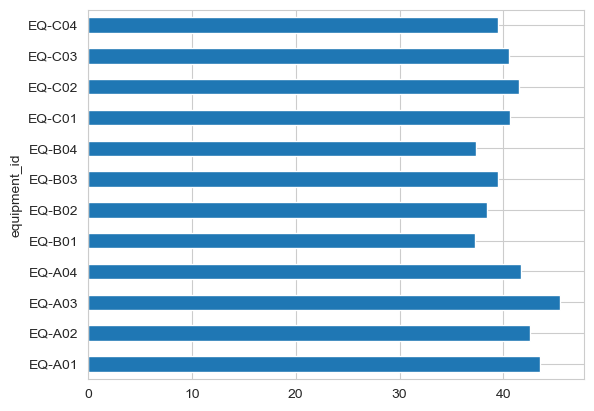

In [86]:
equip_means['temperature_c'].plot(kind='barh')
plt.show()

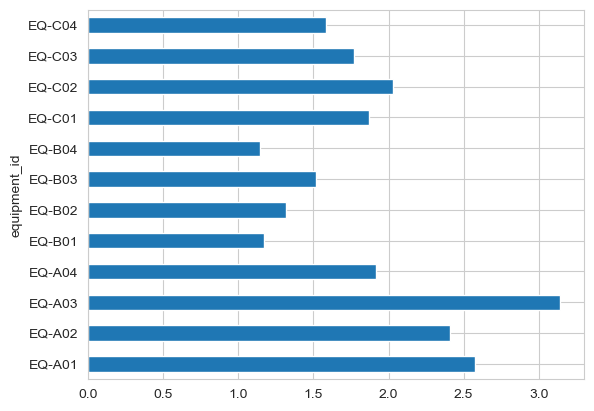

In [87]:
equip_means['vibration_mms'].plot(kind='barh')
plt.show()

In [91]:
equip_means['temperature_c'].idxmax()

'EQ-A03'

In [92]:
equip_means['vibration_mms'].idxmax()

'EQ-A03'

In [ ]:
cols = ['temperature_c','vibration_mms', 'current_a', 'pressure_bar']

In [77]:
stats = sensor.groupby('equipment_id')[cols].agg( ['mean','std','min','max' ] ) 

In [78]:
stats

temperature_c                       vibration_mms            \
                      mean       std   min   max          mean       std   
equipment_id                                                               
EQ-A01           43.490150  2.220436  36.9  61.9      2.573659  0.532509   
EQ-A02           42.583415  2.161427  35.7  62.2      2.407904  0.504642   
EQ-A03           45.494139  2.396841  38.8  66.8      3.144274  0.609298   
EQ-A04           41.693365  2.358822  35.7  64.2      1.919813  0.516785   
EQ-B01           37.277283  2.186085  30.8  54.5      1.169161  0.361971   
EQ-B02           38.439191  2.347167  32.8  57.3      1.314706  0.344503   
EQ-B03           39.480716  2.229717  32.9  61.0      1.515667  0.437205   
EQ-B04           37.397755  2.069789  31.1  54.5      1.142848  0.575367   
EQ-C01           40.671593  2.299828  35.0  62.0      1.866907  0.539387   
EQ-C02           41.548068  2.553043  35.9  63.0      2.031685  0.490799   
EQ-C03           40.587972  2.357205  34.5  58.9      1.770286  0.433346   
EQ-C04           39.489485  2.057740  33.6  56.9      1.580605  0.535282   

                           current_a                       pressure_bar  \
               min    max       mean       std   min   max         mean   
equipment_id                                                              
EQ-A01        1.53  10.49  15.122871  1.197236  11.5  24.0     4.997922   
EQ-A02        1.39  10.28  14.503120  0.991454  11.1  17.7     4.996793   
EQ-A03        1.91  10.66  16.024958  1.002241  12.9  18.8     4.800188   
EQ-A04        0.73   9.66  12.003827  1.010797   8.0  15.5     5.197183   
EQ-B01        0.10   5.78  12.958201  1.001598  10.0  16.8     5.506192   
EQ-B02        0.14   6.88  13.510176  1.019537  10.6  17.2     5.394340   
EQ-B03        0.41   8.42  14.013664  0.997820  11.3  17.5     5.293893   
EQ-B04        0.18   8.88  11.017497  0.999168   7.9  14.6     5.504165   
EQ-C01        0.62   9.39  14.012288  0.996253  10.7  17.3     5.096924   
EQ-C02        0.96   8.77  14.487402  0.966136  11.6  17.5     4.984947   
EQ-C03        0.45   9.54  14.028056  0.992800  10.7  17.8     5.204689   
EQ-C04        0.60   9.29  11.983817  1.001344   8.6  15.2     5.298100   

                                    
                   std   min   max  
equipment_id                        
EQ-A01        0.197943  4.27  5.65  
EQ-A02        0.199427  4.19  5.69  
EQ-A03        0.206069  4.12  5.48  
EQ-A04        0.197567  4.57  5.82  
EQ-B01        0.202980  4.75  6.19  
EQ-B02        0.196680  4.70  6.04  
EQ-B03        0.202121  4.52  5.89  
EQ-B04        0.195073  4.77  6.21  
EQ-C01        0.196273  4.36  5.81  
EQ-C02        0.198208  4.41  5.58  
EQ-C03        0.200189  4.56  6.15  
EQ-C04        0.201181  4.66  5.98

In [ ]:
# 여기에 코드 작성


### 문제 2-2: 센서 시계열 시각화 (5점)

**고장이 발생한 3대 설비(EQ-A03, EQ-C02, EQ-A01)**의 센서 데이터를 시계열로 시각화하세요.

1. 3개 설비 × 2개 센서(온도, 진동) = **3행 2열 서브플롯** (Figure 18×12)
2. 각 차트에 일별 이동평균(7일)도 함께 표시 (빨간 실선)
3. 고장 발생일을 세로 점선으로 표시:
   - EQ-A03: 2024-04-15 (베어링 고장)
   - EQ-C02: 2024-05-20 (과열 정지)
   - EQ-A01: 2024-03-10 (전류 이상)
4. 고장 전 10일간 데이터에 배경색(빨간 음영)을 표시하세요

> **현업 포인트**: 시계열 차트에서 "고장 전에 서서히 올라가는 패턴"을 찾아보세요.

In [129]:
df1

,temperature_c,vibration_mms
0,43.7,3.02
1,45.1,3.54
2,45.7,3.17
3,47.5,2.75
4,42.2,3.18
...,...,...
1778,47.1,3.77
1779,44.8,3.27
1780,45.5,3.52
1781,49.3,3.51


In [95]:
sensor.columns

Index(['sensor_id', 'timestamp', 'equipment_id', 'temperature_c',
       'vibration_mms', 'current_a', 'pressure_bar', 'date', 'month', 'hour',
       'line'],
      dtype='object')

In [133]:
sensor.loc[ sensor['equipment_id'] == 'EQ-A03' ,  ['timestamp','temperature_c','vibration_mms']  ].set_index('timestamp')


,temperature_c,vibration_mms
timestamp,,
2024-01-01 00:00:00,43.7,3.02
2024-01-01 02:00:00,45.1,3.54
2024-01-01 04:00:00,45.7,3.17
2024-01-01 06:00:00,47.5,2.75
2024-01-01 08:00:00,42.2,3.18
...,...,...
2024-06-29 12:00:00,47.1,3.77
2024-06-29 14:00:00,44.8,3.27
2024-06-29 18:00:00,45.5,3.52


In [134]:
df1 = sensor.loc[ sensor['equipment_id'] == 'EQ-A03' ,  ['timestamp','temperature_c','vibration_mms']  ].set_index('timestamp')
df2 = sensor.loc[ sensor['equipment_id'] == 'EQ-C02' ,  ['timestamp','temperature_c','vibration_mms']  ].set_index('timestamp')
df3 = sensor.loc[ sensor['equipment_id'] == 'EQ-A01' ,  ['timestamp','temperature_c','vibration_mms']  ].set_index('timestamp') 

In [104]:
from koreanize_matplotlib import koreanize
koreanize()

In [118]:
12 * 7

84

In [135]:
df4 = df1.rolling(window= 84).mean().copy()

In [136]:
df5 = df2.rolling(window= 84).mean().copy()

In [137]:
df6 = df3.rolling(window= 84).mean().copy()

In [141]:
fail_date = pd.Timestamp('2024-04-15')

In [142]:
fail_date

Timestamp('2024-04-15 00:00:00')

In [ ]:
#2024-05-20

In [149]:
fail_date2 = pd.Timestamp('2024-05-20')

In [ ]:
#2024-03-10

In [150]:
fail_date3 = pd.Timestamp('2024-03-10')

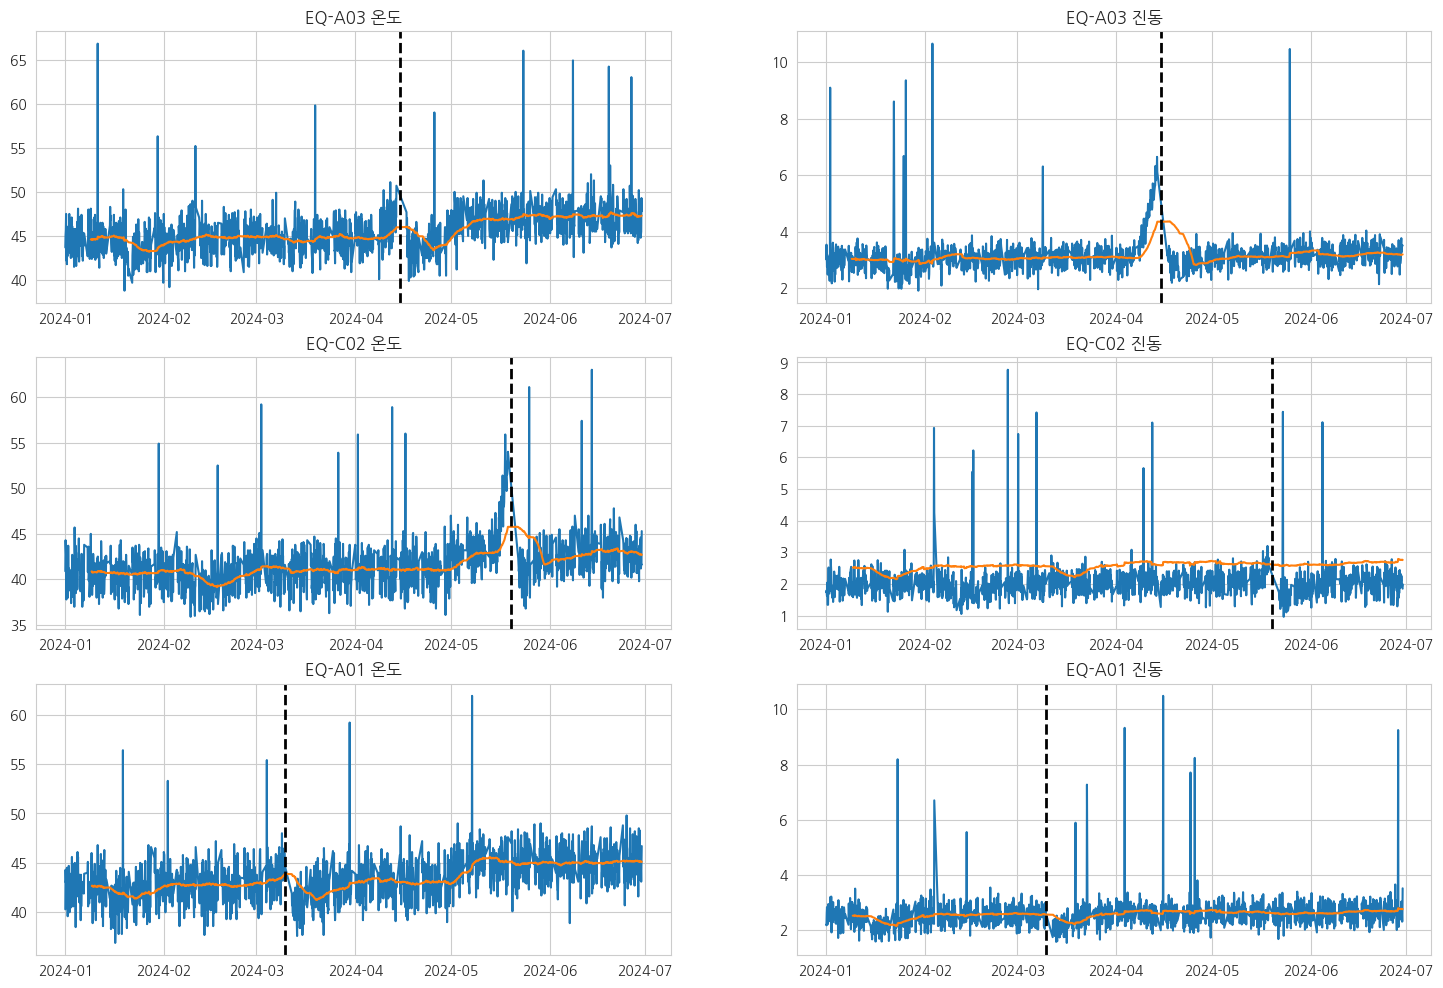

In [151]:
fig, axes = plt.subplots(3, 2, figsize=(18,12))
axes[0,0].plot(df1.index, df1['temperature_c'])
axes[0,0].plot(df4.index, df4['temperature_c'])

axes[0,0].axvline(fail_date, color='black', linestyle='--', linewidth=2, label='고장일 2024-04-15')

axes[0,1].plot(df1.index, df1['vibration_mms'])
axes[0,1].plot(df4.index, df4['vibration_mms'])

axes[0,1].axvline(fail_date, color='black', linestyle='--', linewidth=2, label='고장일 2024-04-15')

axes[0,0].set_title('EQ-A03 온도')
axes[0,1].set_title('EQ-A03 진동')

axes[1,0].plot(df2.index, df2['temperature_c'])
axes[1,0].plot(df5.index, df5['temperature_c'])

axes[1,0].axvline(fail_date2, color='black', linestyle='--', linewidth=2, label='고장일')

axes[1,1].plot(df2.index, df2['vibration_mms'])
axes[1,1].plot(df6.index, df6['vibration_mms'])

axes[1,1].axvline(fail_date2, color='black', linestyle='--', linewidth=2, label='고장일')


axes[1,0].set_title('EQ-C02 온도')
axes[1,1].set_title('EQ-C02 진동')

axes[2,0].plot(df3.index, df3['temperature_c'])
axes[2,0].plot(df6.index, df6['temperature_c'])

axes[2,0].axvline(fail_date3, color='black', linestyle='--', linewidth=2, label='고장일')


axes[2,1].plot(df3.index, df3['vibration_mms'])
axes[2,1].plot(df6.index, df6['vibration_mms'])

axes[2,1].axvline(fail_date3, color='black', linestyle='--', linewidth=2, label='고장일')

axes[2,0].set_title('EQ-A01 온도')
axes[2,1].set_title('EQ-A01 진동')

plt.show()

In [ ]:
# 여기에 코드 작성


### 문제 2-3: 3-Sigma 이상탐지 (10점)

가장 기본적인 이상탐지 방법입니다.  
평균 ± 3σ를 벗어나는 점을 이상으로 판정합니다.

1. **설비별**로 각 센서의 평균(μ)과 표준편차(σ)를 계산
2. `|x - μ| > 3σ`인 점을 이상치로 판정하여 `is_anomaly_temp`, `is_anomaly_vib` 컬럼 추가
3. 설비별 이상치 건수를 집계하세요
4. **EQ-A03의 진동 데이터**를 시계열로 그리고, 이상치를 빨간 점으로 표시하세요
   - μ ± 3σ 범위를 회색 음영으로 표시 (`axhspan`)
5. 이 방법의 한계점은 무엇인가? (고장 전 서서히 증가하는 패턴을 탐지할 수 있는가?)

In [ ]:
# 여기에 코드 작성


### 문제 2-4: 이동평균 기반 이상탐지 (10점)

3-Sigma는 전체 기간 평균 기준이라 **점진적 변화**를 놓칩니다.  
**이동평균 기반 탐지**는 최근 데이터 기준으로 이상을 판단합니다.

1. EQ-A03의 진동 데이터에 대해:
   - **24시간 이동평균** (rolling, window=12, 2시간 간격이므로)
   - **24시간 이동표준편차**
   - 동적 상한: 이동평균 + 2 × 이동표준편차
   - 동적 하한: 이동평균 - 2 × 이동표준편차

2. 실제 값이 동적 상/하한을 벗어나는 점을 이상으로 판정

3. 시계열 차트로 시각화:
   - 실제값 (파란 선)
   - 이동평균 (녹색 선)
   - 동적 상/하한 (회색 음영)
   - 이상점 (빨간 점)
   - 고장일 세로선
   - Figure 크기: (16, 6)

4. **7일 이동평균**으로도 같은 분석을 수행하고, 24시간 vs 7일 중 어느 것이  
   고장 전조를 더 잘 탐지하는지 비교하세요

In [ ]:
# 여기에 코드 작성


---
## Part 3: 고장 전조 패턴 분석 (20점)

이상탐지를 넘어, **고장 발생 전에 어떤 패턴이 나타나는지** 구체적으로 분석합니다.  
이 패턴을 알면 향후 고장을 예측할 수 있습니다.

> **현업 포인트**: 고장 전 10일 → 7일 → 3일 → 1일 시점의 센서값 변화를 추적하면  
> "몇 일 전부터 이상 징후가 나타나는지" 파악할 수 있습니다.

### 문제 3-1: 고장 전 센서 변화율 분석 (10점)

3건의 고장(EQ-A03 4/15, EQ-C02 5/20, EQ-A01 3/10)에 대해:

1. 고장 전 14일간의 **일별 평균 센서값**을 추출하세요
2. 정상 기간(고장 30일 전 ~ 15일 전) 대비 **변화율(%)**을 계산하세요
   - 변화율 = (고장전 값 - 정상기간 평균) / 정상기간 평균 × 100
3. 3건의 고장 각각에 대해 **고장 D-14 ~ D-0의 센서 변화율**을 라인 차트로 시각화
   - 1×3 서브플롯 (EQ-A03 진동, EQ-C02 온도, EQ-A01 전류)
   - x축: D-14, D-13, ..., D-1, D-0
   - y축: 변화율 (%)
4. 각 고장에서 **가장 먼저 10% 이상 변화**가 나타나는 시점(D-?)을 확인하세요

In [ ]:
# 여기에 코드 작성


### 문제 3-2: 정비 이력과 센서 상관관계 (10점)

1. `maint` 테이블에서 CM(고장수리) 건만 필터링
2. 각 고장수리 발생일 **전 7일간**의 평균 센서값(온도, 진동)과  
   **평상시** 평균 센서값을 비교하는 표를 만드세요
3. 예방정비(PM) 전후 7일간의 센서값 변화도 비교하세요
   - PM 전 7일 평균 vs PM 후 7일 평균
   - **예방정비 효과**가 센서값으로 확인되는가?
4. **라인별 고장 건수**, **라인별 PM 건수**, **설비 나이**를 결합하여  
   PM을 잘 지킨 라인이 고장이 적은지 확인하세요

In [ ]:
# 여기에 코드 작성


---
## Part 4: 설비 건강도 스코어링 (20점)

개별 센서 분석을 넘어, 설비의 **종합적인 건강 상태**를 점수화합니다.  
이를 통해 어떤 설비를 우선 정비해야 하는지 의사결정할 수 있습니다.

> **현업 포인트**: 설비 건강도 = f(센서 상태, 가동시간, 정비이력, 알람빈도)

### 문제 4-1: 설비 건강도 지표 설계 (10점)

다음 5가지 지표로 설비 건강도를 계산하세요 (각 지표 0~100점 정규화):

| 지표 | 계산 방법 | 가중치 |
|------|----------|--------|
| 센서 이상 점수 | 최근 30일 이상치 비율 (낮을수록 좋음) | 30% |
| 진동 수준 점수 | 최근 30일 평균 진동 (낮을수록 좋음) | 25% |
| 정비 이행률 | PM 건수 / 예정 PM 건수 (높을수록 좋음) | 20% |
| 고장 빈도 점수 | CM 건수 (적을수록 좋음) | 15% |
| 알람 빈도 점수 | 알람 건수 (적을수록 좋음) | 10% |

1. 각 지표를 0~100으로 정규화하세요 (min-max 또는 순위 기반)
   - 100점 = 최상 상태, 0점 = 최악 상태
2. 가중 평균으로 **종합 건강도 점수**를 계산
3. 설비별 건강도를 표로 출력 (내림차순)
4. 건강도 점수별 등급 부여:
   - A등급(80+), B등급(60~80), C등급(40~60), D등급(40 미만)

In [ ]:
# 여기에 코드 작성


### 문제 4-2: 설비 건강도 대시보드 (10점)

**2행 2열 (4패널)** 대시보드를 만드세요. Figure 크기: (16, 12)

| 위치 | 차트 | 내용 |
|------|------|------|
| (1,1) | 수평 바 차트 | 설비별 건강도 점수 (등급별 색상) |
| (1,2) | 히트맵 | 설비 × 5개 지표 점수 매트릭스 |
| (2,1) | 라인 차트 | 고장 설비(EQ-A03) 진동 시계열 + 이동평균 + 고장일 |
| (2,2) | 산점도 | 설비 나이 vs 건강도 점수 (크기=누적가동시간) |

전체 제목: '설비 건강도 모니터링 대시보드 (2024년 6월 기준)'

In [ ]:
# 여기에 코드 작성


---
## Part 5: 예지보전 전략 제안 (15점)

### 문제 5-1: 종합 분석 및 전략 제안 (15점)

분석 결과를 바탕으로 아래 항목을 **마크다운 셀에** 작성하세요.

1. **현재 설비 상태 요약**: 건강도 등급별 설비 분포
2. **고장 전조 패턴**: 어떤 센서가, 몇 일 전부터 변화하는가?
3. **이상탐지 방법 비교**: 3-Sigma vs 이동평균 기반, 각각의 장단점
4. **예방정비 효과**: PM이 센서값과 고장빈도에 미치는 영향
5. **우선 조치 대상 설비**: 건강도 기준 하위 3대 설비와 조치 방안
6. **예지보전 시스템 제안**:
   - 어떤 센서를 우선 모니터링할 것인가?
   - 알람 임계값은 어떻게 설정할 것인가?
   - PM 주기를 어떻게 최적화할 것인가?

### 분석 결론 (여기에 작성)

1. **현재 설비 상태 요약**: 

2. **고장 전조 패턴**: 

3. **이상탐지 방법 비교**: 

4. **예방정비 효과**: 

5. **우선 조치 대상**: 

6. **예지보전 시스템 제안**: 


---
## 수고하셨습니다!

### 학습 체크리스트
- [ ] 시계열 센서 데이터 보간(interpolation) 처리
- [ ] 설비별 센서 기본 통계 비교
- [ ] 이동평균과 시계열 시각화
- [ ] 3-Sigma 이상탐지 구현 및 시각화
- [ ] 이동평균 기반 동적 이상탐지
- [ ] 고장 전조 패턴 (D-14 ~ D-0) 변화율 분석
- [ ] 정비 이력과 센서 데이터 연계 분석
- [ ] 설비 건강도 스코어링 설계 및 계산
- [ ] 4패널 대시보드 구성
- [ ] 데이터 기반 예지보전 전략 제안